<a href="https://colab.research.google.com/github/bajon1/Deep-learning-lab/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install optuna statsmodels -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, KFold
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import optuna
from statsmodels.stats.contingency_tables import cochrans_q
import torch.nn.functional as F
from scipy import stats

# Lab 3: MLP – trening configuration

# Task 1: MLP implementation for MNIST

#### Goal: Build a multi-layer network to classify flattened MNIST images.

```python
# Load flattened MNIST images (vectors of dimension 784) from scikit-learn
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]
X = X.astype(np.float32) / 255.0 # scale to [0, 1]
y = y.astype(np.int64)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)
```

1. Define an MLP with architecture: input=784 → hidden=1568 → hidden=1568 → output=10.
2. Use SGD optimiser, CrossEntropyLoss, and a learning rate of 0.01.
3. Split the trainval set into five folds using 5-fold cross-validation.
4. Train in mini-batches of 1024 images; each epoch consumes all training images. Set the model to model.train() mode during training.
5. After each training epoch, switch to model.eval() mode, run inference on the validation fold, and compute the mean validation loss. Whenever the validation loss reaches a new minimum, save a checkpoint containing: model state dict, optimiser state dict, epoch number, best validation loss, and the full list of training/validation losses across all completed epochs.
6. Plot validation and training loss as a function of epoch.
7. Train a separate model for each fold — the result is five independent models used in Task 2.

In [2]:
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
device

device(type='cuda')

In [3]:
from tensorflow.keras.datasets import mnist as keras_mnist
from sklearn.model_selection import train_test_split
import numpy as np

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras_mnist.load_data()

X = np.concatenate([X_train_raw, X_test_raw]).reshape(-1, 784).astype(np.float32) / 255.0
y = np.concatenate([y_train_raw, y_test_raw]).astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(784, 1568),
        nn.ReLU(),
        nn.Linear(1568, 1568),
        nn.ReLU(),
        nn.Linear(1568, 10)
    )
  def forward(self, x):
    logits = self.layers(x)
    return logits

# alternative mlp without sequential

class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.input = nn.Linear(784, 1568)
    self.hidden = nn.Linear(1568, 1568)
    self.output = nn.Linear(1568, 10)

    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.input(x))
    x = self.relu(self.hidden(x))
    x = self.output(x)
    return x

In [5]:
lr = 1e-2
criterion = nn.CrossEntropyLoss()

In [6]:
splits = 5
kfold = KFold(n_splits=splits, shuffle = True)

X_trainval =  torch.tensor(X_trainval, dtype = torch.float32)
y_trainval = torch.tensor(y_trainval, dtype = torch.long)
X_test =  torch.tensor(X_test, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.long).to(device)

In [7]:
EPOCHS = 100
fold_models = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):

  best_val_loss = np.inf
  train_losses = []
  val_losses = []

  X_train, y_train = X_trainval[train_idx].to(device), y_trainval[train_idx].to(device)
  X_val, y_val = X_trainval[val_idx].to(device), y_trainval[val_idx].to(device)

  model = MLP().to(device)
  optim = torch.optim.SGD(model.parameters(), lr=lr)

  train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True)

  for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      optim.zero_grad()
      loss = criterion(model(X_batch), y_batch)
      loss.backward()
      optim.step()
      train_loss += loss.item() * len(X_batch)

    train_losses.append(train_loss / len(X_train))

    model.eval()
    with torch.no_grad():
      val_loss = criterion(model(X_val), y_val).item()
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      checkpoint = {
          'model_state': model.state_dict(),
          'optim_state': optim.state_dict(),
          'epoch': epoch,
          'best_val_loss': best_val_loss,
          'train_losses': train_losses.copy(),
          'val_losses': val_losses.copy()
      }

  fold_models.append(checkpoint)
  print(f"Fold {fold+1}/5 — best val loss: {best_val_loss:.4f}")

Fold 1/5 — best val loss: 0.2689
Fold 2/5 — best val loss: 0.2744
Fold 3/5 — best val loss: 0.2756
Fold 4/5 — best val loss: 0.2681
Fold 5/5 — best val loss: 0.2706


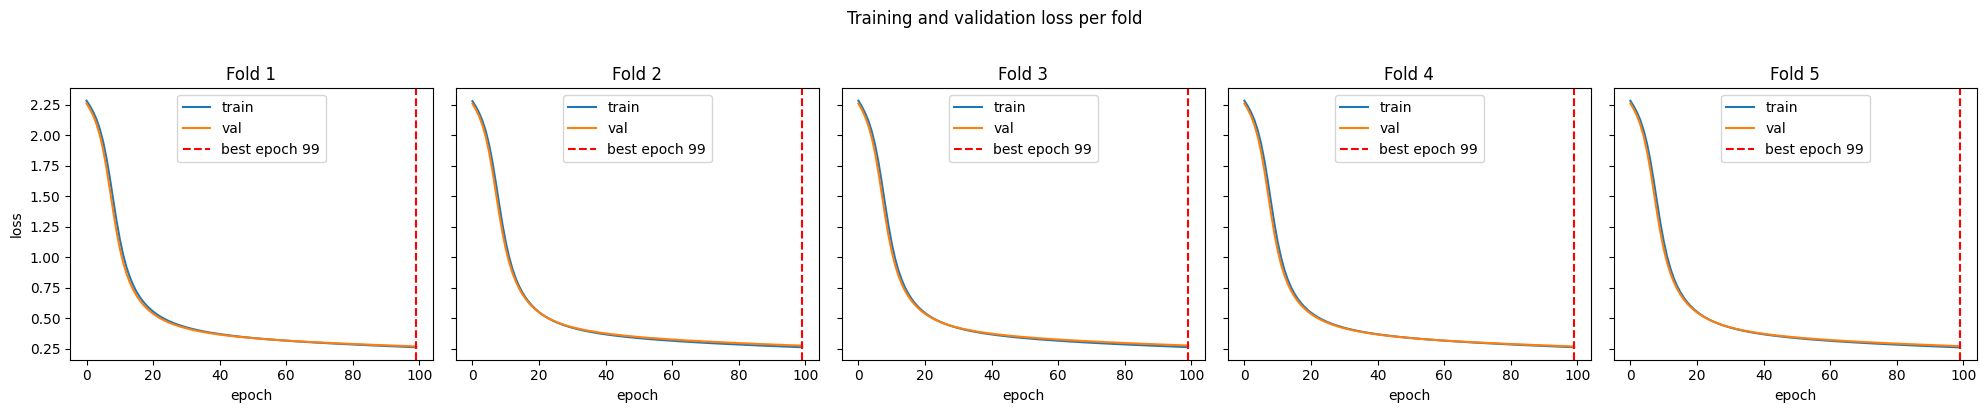

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for fold, checkpoint in enumerate(fold_models):
    ax = axes[fold]
    ax.plot(checkpoint['train_losses'], label='train')
    ax.plot(checkpoint['val_losses'],   label='val')
    ax.axvline(checkpoint['epoch'], color='red', linestyle='--', label=f"best epoch {checkpoint['epoch']}")
    ax.set_title(f'Fold {fold+1}')
    ax.set_xlabel('epoch')
    if fold == 0:
        ax.set_ylabel('loss')
    ax.legend()

plt.suptitle('Training and validation loss per fold', y=1.02)
plt.tight_layout()
plt.show()

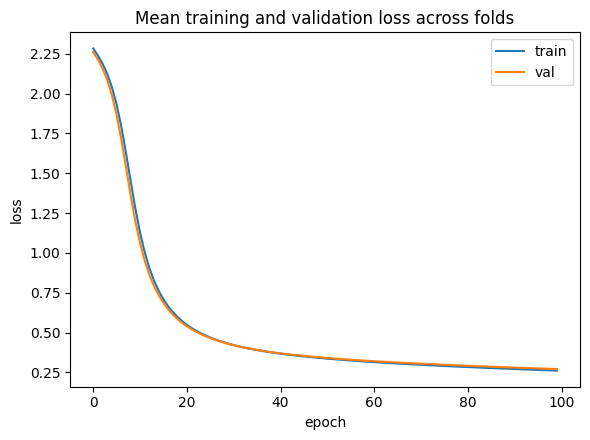

In [9]:
min_epochs = min(len(cp['train_losses']) for cp in fold_models)

mean_train = np.mean([cp['train_losses'][:min_epochs] for cp in fold_models], axis=0)
mean_val   = np.mean([cp['val_losses'][:min_epochs]   for cp in fold_models], axis=0)

plt.figure(figsize=(6, 4.5))
plt.plot(mean_train, label='train')
plt.plot(mean_val,   label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Mean training and validation loss across folds')
plt.legend()
plt.tight_layout()
plt.show()

# Task 2: Inference and prediction uncertainty

#### Goal: Evaluate prediction uncertainty using ensemble methods.

1. Majority voting — run all five models, obtain the argmax class from each, and return the class chosen by the majority.
2. Mean response — run all five models, average the softmax probabilities across models, and return the argmax of the averaged distribution.
3. Use Shannon entropy to estimate prediction uncertainty for both ensemble variants. How does entropy differ between confident and uncertain predictions?
4. Report test-set accuracy for both variants.
5. Use Cochran's Q test to determine whether the accuracy difference between the two methods is statistically significant.

In [11]:

def majority_voting(models, X, y):

  preds = []

  for model in models:
    with torch.no_grad():
      model.eval()
      logits = model(X)

      pred_list = F.softmax(logits, dim=1).argmax(dim=1) #argmax(logits, dim=1) does the same
      preds.append(pred_list)

  preds = torch.stack(preds, dim=0).cpu().numpy()

  probs = np.zeros((len(y), 10))
  for i in range(10):
    probs[:, i] = (preds == i).sum(axis=0) / len(models)

  final_preds = stats.mode(preds, axis=0, keepdims=True).mode.flatten()

  accuracy = (final_preds == y.cpu().numpy()).mean()
  entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1).mean()

  print("Predictions:", final_preds, "\nAccuracy: ", accuracy, "\nShannon entropy", entropy)

  return final_preds

In [12]:

def mean_response(models, X, y):
  probs = []

  for model in models:
    with torch.no_grad():
      model.eval()
      logits = model(X)

      prob = F.softmax(logits, dim=1)
      probs.append(prob.cpu().numpy())

  probs = np.stack(probs, axis=0)
  mean_probs = probs.mean(axis=0)
  final_preds = mean_probs.argmax(axis=1)

  accuracy = (final_preds == y.cpu().numpy()).mean()
  entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-9), axis=1).mean()

  print("Predictions:", final_preds, "\nAccuracy: ", accuracy, "\nShannon entropy", entropy)

  return final_preds

In [13]:
models = []

for checkpoint in fold_models:
  model = MLP().to(device)
  model.load_state_dict(checkpoint['model_state'])

  models.append(model)

print("Majority voting ensemble: ")
mv_preds = majority_voting(models, X_test, y_test)

print("\nMean response ensemble: ")
mr_preds = mean_response(models, X_test, y_test)

y_np = y_test.cpu().numpy()

binary_matrix = np.stack([(mv_preds == y_np).astype(int), (mr_preds == y_np).astype(int)], axis=1)
print("\nCochrans q test metrics:", cochrans_q(binary_matrix))

Majority voting ensemble: 
Predictions: [7 4 5 ... 6 4 3] 
Accuracy:  0.9217 
Shannon entropy 0.015120553774324261

Mean response ensemble: 
Predictions: [7 4 5 ... 6 4 3] 
Accuracy:  0.9216 
Shannon entropy 0.3321706

Cochrans q test metrics: df          1
pvalue      0.8473896596867143
statistic   0.037037037037037035


# Task 3: Learning rate selection

#### Goal: Find an optimal learning rate using automated hyperparameter search.

1. Implement an objective_lr function for Optuna that trains the network for a small number of epochs and returns the mean 5-fold cross-validation loss on the validation set.
2. Run the Optuna study to find the optimal learning rate.
3. Retrain the full model using the optimal learning rate found, following the same procedure as Task 1.
4. Compare loss curves between the fixed LR from Task 1 and the Optuna-optimised LR using a side-by-side plot.

In [14]:
from tensorflow.keras.datasets import mnist as keras_mnist
from sklearn.model_selection import train_test_split
import numpy as np

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras_mnist.load_data()

X = np.concatenate([X_train_raw, X_test_raw]).reshape(-1, 784).astype(np.float32) / 255.0
y = np.concatenate([y_train_raw, y_test_raw]).astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)

X_trainval =  torch.tensor(X_trainval, dtype = torch.float32)
y_trainval = torch.tensor(y_trainval, dtype = torch.long)
X_test =  torch.tensor(X_test, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.long).to(device)

In [21]:
def objective_lr(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    fold_losses = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):
        X_train = X_trainval[train_idx].to(device)
        y_train = y_trainval[train_idx].to(device)
        X_val = X_trainval[val_idx].to(device)
        y_val = y_trainval[val_idx].to(device)

        train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True)

        model = MLP().to(device)
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)

        for epoch in range(5):
            model.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(X_batch), y_batch)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            fold_loss = criterion(model(X_val), y_val).item()
        fold_losses.append(fold_loss)

    return np.mean(fold_losses)

study = optuna.create_study(direction='minimize')
study.optimize(objective_lr, n_trials=20)

best_lr = study.best_params['lr']
print(f"Best learning rate: {best_lr:.6f}")
print(f"Best kfold mean loss: {study.best_value:.4f}")

[I 2026-04-26 11:48:17,230] A new study created in memory with name: no-name-2a02eca2-0055-4a5c-a3cc-6339c8b5ab6b
[I 2026-04-26 11:48:34,630] Trial 0 finished with value: 2.2883370399475096 and parameters: {'lr': 0.0007147856317899753}. Best is trial 0 with value: 2.2883370399475096.
[I 2026-04-26 11:48:46,867] Trial 1 finished with value: 2.3031335353851317 and parameters: {'lr': 3.3371684090442655e-05}. Best is trial 0 with value: 2.2883370399475096.
[I 2026-04-26 11:49:00,035] Trial 2 finished with value: 2.298381805419922 and parameters: {'lr': 0.00016938476057799944}. Best is trial 0 with value: 2.2883370399475096.
[I 2026-04-26 11:49:13,396] Trial 3 finished with value: 0.6545208692550659 and parameters: {'lr': 0.03304629536443981}. Best is trial 3 with value: 0.6545208692550659.
[I 2026-04-26 11:49:28,202] Trial 4 finished with value: 2.303073501586914 and parameters: {'lr': 5.190397101089293e-05}. Best is trial 3 with value: 0.6545208692550659.
[I 2026-04-26 11:49:40,633] Trial

Best learning rate: 0.098102
Best kfold mean loss: 0.3473


In [22]:
best_lr = study.best_params['lr']
EPOCHS = 100
fold_models_optuna = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):
    best_val_loss = np.inf
    train_losses_optuna = []
    val_losses_optuna = []

    X_train, y_train = X_trainval[train_idx].to(device), y_trainval[train_idx].to(device)
    X_val, y_val = X_trainval[val_idx].to(device),   y_trainval[val_idx].to(device)

    model_optuna = MLP().to(device)
    optimizer_optuna = torch.optim.SGD(model_optuna.parameters(), lr=best_lr)
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True)

    for epoch in range(EPOCHS):
        model_optuna.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer_optuna.zero_grad()
            loss = criterion(model_optuna(X_batch), y_batch)
            loss.backward()
            optimizer_optuna.step()
            train_loss += loss.item() * len(X_batch)

        train_losses_optuna.append(train_loss / len(X_train))

        model_optuna.eval()
        with torch.no_grad():
            val_loss = criterion(model_optuna(X_val), y_val).item()
        val_losses_optuna.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            checkpoint_optuna = {
                'model_state':   model_optuna.state_dict(),
                'optim_state':   optimizer_optuna.state_dict(),
                'epoch':         epoch,
                'best_val_loss': best_val_loss,
                'train_losses':  train_losses_optuna.copy(),
                'val_losses':    val_losses_optuna.copy()
            }

    fold_models_optuna.append(checkpoint_optuna)
    print(f"Fold {fold+1}/5 — best val loss: {best_val_loss:.4f}")

Fold 1/5 — best val loss: 0.0878
Fold 2/5 — best val loss: 0.0783
Fold 3/5 — best val loss: 0.0831
Fold 4/5 — best val loss: 0.0789
Fold 5/5 — best val loss: 0.0759


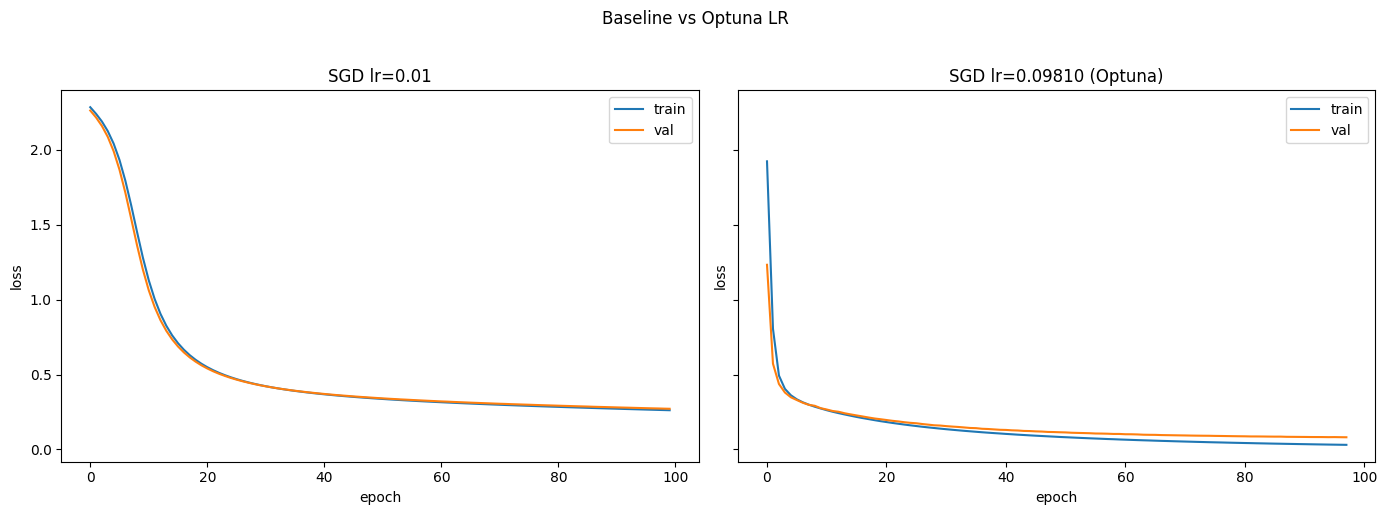

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, fold_models_list, title in zip(
    axes,
    [fold_models, fold_models_optuna],
    [f'SGD lr=0.01', f'SGD lr={best_lr:.5f} (Optuna)']
):
    min_epochs = min(len(cp['train_losses']) for cp in fold_models_list)
    mean_train = np.mean([cp['train_losses'][:min_epochs] for cp in fold_models_list], axis=0)
    mean_val   = np.mean([cp['val_losses'][:min_epochs]   for cp in fold_models_list], axis=0)

    ax.plot(mean_train, label='train')
    ax.plot(mean_val,   label='val')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Baseline vs Optuna LR', y=1.02)
plt.tight_layout()
plt.show()

# Task 4: Optimiser comparison

#### Goal: Investigate how the choice of optimiser affects training performance.

1. Train the model with SGD using default PyTorch parameters.
2. Train the model with Adam using default PyTorch parameters.
3. Use Optuna to optimise SGD hyperparameters: momentum, nesterov, and learning_rate.
4. Use Optuna to optimise Adam hyperparameters: betas and learning_rate.
5. Compare all four configurations — plot training and validation loss curves for each.

In [ ]:
from tensorflow.keras.datasets import mnist as keras_mnist
from sklearn.model_selection import train_test_split
import numpy as np

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras_mnist.load_data()

X = np.concatenate([X_train_raw, X_test_raw]).reshape(-1, 784).astype(np.float32) / 255.0
y = np.concatenate([y_train_raw, y_test_raw]).astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)

X_trainval =  torch.tensor(X_trainval, dtype = torch.float32)
y_trainval = torch.tensor(y_trainval, dtype = torch.long)
X_test =  torch.tensor(X_test, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.long).to(device)

splits = 5
kfold = KFold(n_splits=splits, shuffle = True)

In [25]:
EPOCHS = 100
fold_models_sgd = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):

  best_val_loss = np.inf
  train_losses = []
  val_losses = []

  X_train, y_train = X_trainval[train_idx].to(device), y_trainval[train_idx].to(device)
  X_val, y_val = X_trainval[val_idx].to(device), y_trainval[val_idx].to(device)

  model = MLP().to(device)
  optim = torch.optim.SGD(model.parameters())

  train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True)

  for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      optim.zero_grad()
      loss = criterion(model(X_batch), y_batch)
      loss.backward()
      optim.step()
      train_loss += loss.item() * len(X_batch)

    train_losses.append(train_loss / len(X_train))

    model.eval()
    with torch.no_grad():
      val_loss = criterion(model(X_val), y_val).item()
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      checkpoint = {
          'model_state': model.state_dict(),
          'optim_state': optim.state_dict(),
          'epoch': epoch,
          'best_val_loss': best_val_loss,
          'train_losses': train_losses.copy(),
          'val_losses': val_losses.copy()
      }

  fold_models.append(checkpoint)
  print(f"Fold {fold+1}/5 — best val loss: {best_val_loss:.4f}")

Fold 1/5 — best val loss: 1.1489
Fold 2/5 — best val loss: 1.1877
Fold 3/5 — best val loss: 1.1649
Fold 4/5 — best val loss: 1.1552
Fold 5/5 — best val loss: 1.1798


In [29]:
def objective_sgd(trial):
  lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
  momentum = trial.suggest_float('momentum', 0.00, 0.99)
  nesterov = trial.suggest_categorical('nesterov', [True, False])
  if nesterov and momentum == 0.0:
    momentum = 0.01

  sgd_fold_losses = []

  for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):
    X_train = X_trainval[train_idx].to(device)
    y_train = y_trainval[train_idx].to(device)
    X_val = X_trainval[val_idx].to(device)
    y_val = y_trainval[val_idx].to(device)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size = 1024, shuffle = True)

    model = MLP().to(device)
    optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, nesterov=nesterov)

    for epoch in range(20):
      model.train()
      for X_batch, y_batch in train_loader:
        optim.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optim.step()

      model.eval()
      with torch.no_grad():
        sgd_fold_loss = criterion(model(X_val), y_val).item()
      sgd_fold_losses.append(sgd_fold_loss)

      return np.mean(sgd_fold_losses)

sgd_study = optuna.create_study(direction='minimize')
sgd_study.optimize(objective_sgd, n_trials=20)

best_sgd_lr = sgd_study.best_params['lr']
best_sgd_momentum = sgd_study.best_params['momentum']
best_sgd_nesterov = sgd_study.best_params['nesterov']
print(f"Best sgd learning rate: {best_sgd_lr:.4f}")
print(f"Best sgd momentum: {best_sgd_momentum:.4f}")
print(f"Best sgd nesterov: {best_sgd_nesterov}")
print(f"Best sgd kfold mean loss: {sgd_study.best_value:.4f}")

[I 2026-04-26 12:41:12,996] A new study created in memory with name: no-name-edbdf23d-ea3f-4752-b343-d8dfa38f0820
[I 2026-04-26 12:41:13,631] Trial 0 finished with value: 0.45956867933273315 and parameters: {'lr': 0.07571100200502419, 'momentum': 0.7473108054417786, 'nesterov': False}. Best is trial 0 with value: 0.45956867933273315.
[I 2026-04-26 12:41:14,241] Trial 1 finished with value: 2.3019635677337646 and parameters: {'lr': 0.00012733888491999533, 'momentum': 0.5846537726402581, 'nesterov': True}. Best is trial 0 with value: 0.45956867933273315.
[I 2026-04-26 12:41:14,817] Trial 2 finished with value: 2.302232503890991 and parameters: {'lr': 0.00036138954052667224, 'momentum': 0.2444891426524615, 'nesterov': False}. Best is trial 0 with value: 0.45956867933273315.
[I 2026-04-26 12:41:15,794] Trial 3 finished with value: 2.270308256149292 and parameters: {'lr': 0.00357902515899584, 'momentum': 0.5119472874065468, 'nesterov': True}. Best is trial 0 with value: 0.45956867933273315.

Best sgd learning rate: 0.0774
Best sgd momentum: 0.8580
Best sgd nesterov: False
Best sgd kfold mean loss: 0.3719


# Task 5: Dropout

#### Goal: Explore Dropout as a regulariser and as a tool for uncertainty estimation.

1. Add nn.Dropout layers to the MLP from Task 1.
2. Train using the same procedure as Task 1.
3. Evaluate whether adding dropout improves test-set accuracy. Use the Mean Response ensemble strategy with the model in model.eval() mode.
4. Monte Carlo Dropout — keep the model in model.train() mode during inference and query the model multiple times for the same fixed input. Observe how the output distribution varies. Estimate prediction uncertainty for: (a) an input that IS a handwritten digit, and (b) an input that is NOT a handwritten digit.